# 미니 프로젝트 - Movielens 영화 SBR

## data train val test를 나눌때 주의

1. 프로젝트 진행시 마주치는 많은 문제들
    1. 기존 노드처럼 1일치만 valid 데이터셋을 가져오면 데이터가 너무 적습니다 7일치정도는 가져오는게 좋아요
    2. 데이터가 적어서 세션이 1개만있는 경우가 많습니다 tr val test를 나눈뒤 데이터 정제를 해보세요
    3. 그외 등등.. 
    


In [1]:
import pandas
import tensorflow

print(pandas.__version__)
print(tensorflow.__version__)

1.3.3
2.6.0


In [2]:
import datetime as dt
from pathlib import Path
import os
import time
from datetime import datetime
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 사용자의 홈 디렉토리 아래에 있는 데이터 경로 설정
data_path = Path(os.getenv('HOME') + '/aiffel/yoochoose/data/')  
# 학습에 사용할 ratings.dat 파일 경로 지정
train_path = data_path / 'ratings.dat'
train_path

PosixPath('/aiffel/aiffel/yoochoose/data/ratings.dat')

# 데이터 전처리

In [4]:
def load_data(data_path: Path, nrows=None):
    # ratings.dat 파일을 불러오며, ::로 구분된 4개의 열을 읽음
    data = pd.read_csv(
        data_path,
        sep='::',                       # 항목 구분자는 "::"
        header=None,                    # 파일에 헤더가 없으므로 직접 지정 예정
        usecols=[0, 1, 2, 3],           # 사용할 열: UserId, ItemId, Rating, Time
        dtype={0: np.int32, 1: np.int32, 2: np.int32},  # 데이터 타입을 정수로 지정
        nrows=nrows                     # 읽을 행 수 제한 (None이면 전체)
    )
    
    # 열 이름을 수동으로 지정
    data.columns = ['UserId', 'ItemId', 'Rating', 'Time']
    
    # Time 컬럼을 Unix timestamp → datetime 형식으로 변환
    data['Time'] = pd.to_datetime(data['Time'], unit='s')
    
    return data

# 전체 데이터를 불러옴
data = load_data(train_path, None)

data.sort_values(['UserId', 'Time'], inplace=True)  
# data를 id와 시간 순서로 정렬해줍니다.
data

,UserId,ItemId,Rating,Time
31,1,3186,4,2000-12-31 22:00:19
22,1,1270,5,2000-12-31 22:00:55
27,1,1721,4,2000-12-31 22:00:55
37,1,1022,5,2000-12-31 22:00:55
24,1,2340,3,2000-12-31 22:01:43
...,...,...,...,...
1000019,6040,2917,4,2001-08-10 14:40:29
999988,6040,1921,4,2001-08-10 14:41:04
1000172,6040,1784,3,2001-08-10 14:41:04
1000167,6040,161,3,2001-08-10 14:41:26


SessionID 대신 USERID 항목이 들어있음 
- 명확한 1회 세션의 SessionID를 포함하지 않음
- UserID가 SessionID 역할을 해야함
- 실습에는 부재했던 Rating 정보가 포함됨
- 이전 실습 내역에서는 이런 항목이 포함되어 있지 않았으므로, 무시하고 제외할 수도 있지만, 직전에 봤던 영화가 맘에 들었는지가 고려하는 것이 의미있을 수도 있음.
- 아울러, Rating이 낮은 데이터를 어떻게 처리할지도 고민해 봐야할 문제임.
- Time 항목에는 UTC time 가 포함되어, 1970년 1월 1일부터 경과된 초 단위 시간이 기재되어 있습니다.

In [5]:
user_counts = data['UserId'].value_counts()

In [6]:
print(user_counts)

4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
        ... 
5725      20
3407      20
1664      20
4419      20
3021      20
Name: UserId, Length: 6040, dtype: int64


In [7]:
user_counts.head(10)

4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
Name: UserId, dtype: int64

In [8]:
user_counts.tail(10)

3969    20
217     20
2488    20
3376    20
665     20
5725    20
3407    20
1664    20
4419    20
3021    20
Name: UserId, dtype: int64

In [9]:
active_users = user_counts[user_counts >= 100]
print(active_users)

4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
        ... 
2975     100
5871     100
1481     100
1567     100
3206     100
Name: UserId, Length: 2945, dtype: int64


# 데이터 조작이 필요한 부분

In [10]:
# 이부분을 이 데이터에 맞게 고치기

# short_session을 제거한 다음 unpopular item을 제거하면 다시 길이가 1인 session이 생길 수 있습니다.
# 이를 위해 반복문을 통해 지속적으로 제거 합니다.
def cleanse_recursive(data: pd.DataFrame, shortest, least_click, duplicated_click=30) -> pd.DataFrame:
    while True:
        before_len = len(data)
        data = cleanse_short_session(data, shortest)
        data = cleanse_unpopular_item(data, least_click)
        data = cleanse_exploitated_review_system(data, duplicated_click)
        after_len = len(data)
        if before_len == after_len:
            break
    return data


def cleanse_short_session(data: pd.DataFrame, shortest):
    session_len = data.groupby('UserId').size()
    session_use = session_len[session_len >= shortest].index
    data = data[data['UserId'].isin(session_use)]
    return data


def cleanse_unpopular_item(data: pd.DataFrame, least_click):
    item_popular = data.groupby('ItemId').size()
    item_use = item_popular[item_popular >= least_click].index
    data = data[data['ItemId'].isin(item_use)]
    return data

# 1분 내 과도한 리뷰(1분 내 60개 초과)를 필터링하여 리뷰 악용 가능성을 제거하는 부분을 추가함
def cleanse_exploitated_review_system(data: pd.DataFrame, max_clicks_in_10min: int):
    data = data.sort_values(['UserId', 'Time'])                      # 사용자별 시간 순 정렬
    data['Time'] = pd.to_datetime(data['Time'])                      # datetime 형식 보장

    keep_indices = []  # 조건을 만족하는 row index만 저장

    for uid, group in data.groupby('UserId'):
        times = group['Time'].values.astype('datetime64[s]').astype(np.int64)  # 초 단위 정수로 변환
        indices = group.index.to_numpy()

        start = 0
        for end in range(len(times)):
            # 1분(60초) 윈도우 유지
            while times[end] - times[start] > 60:
                start += 1
            window_size = end - start + 1
            if window_size <= max_clicks_in_10min:
                keep_indices.append(indices[end])  # 초과하지 않으면 유지

    # 조건을 만족한 인덱스만 반환
    return data.loc[keep_indices].reset_index(drop=True)

In [11]:
# data = cleanse_recursive(data, shortest=2, least_click=5)
# data

In [12]:
# 1) 세션 길이 분포 확인
print("검증 세션 수:", data['UserId'].nunique())
print("세션별 길이(상위 10개):")
print(data.groupby('UserId').size().sort_values(ascending=False).head(10))

# 2) 길이 1인 세션 개수
print("길이 1 세션 비율:",
      (data.groupby('UserId').size() == 1).mean())

검증 세션 수: 6040
세션별 길이(상위 10개):
UserId
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
dtype: int64
길이 1 세션 비율: 0.0


In [13]:
def split_by_date(data: pd.DataFrame, n_days: int):
    final_time = data['Time'].max()
    cutoff_time = final_time - dt.timedelta(days=n_days)

    # Train: cutoff 이전의 데이터
    train = data[data['Time'] < cutoff_time]

    # Test: cutoff 이후의 데이터, 단 아이템은 train에 있던 것만
    test = data[(data['Time'] >= cutoff_time) & (data['ItemId'].isin(train['ItemId']))]

    return train, test

In [14]:
data

,UserId,ItemId,Rating,Time
31,1,3186,4,2000-12-31 22:00:19
22,1,1270,5,2000-12-31 22:00:55
27,1,1721,4,2000-12-31 22:00:55
37,1,1022,5,2000-12-31 22:00:55
24,1,2340,3,2000-12-31 22:01:43
...,...,...,...,...
1000019,6040,2917,4,2001-08-10 14:40:29
999988,6040,1921,4,2001-08-10 14:41:04
1000172,6040,1784,3,2001-08-10 14:41:04
1000167,6040,161,3,2001-08-10 14:41:26


In [15]:
#데이터 부족으로 마지막 31일 데이터 가져옴
tr, test = split_by_date(data, n_days=31)  # 마지막 이틀만 테스트용으로 분리
tr, val = split_by_date(tr, n_days=31)  # 마지막 이틀만 테스트용으로 분리


In [16]:
# data에 대한 정보를 살펴봅니다.
def stats_info(data: pd.DataFrame, status: str):
    print(f'* {status} Set Stats Info\n'
          f'\t Events: {len(data)}\n'
          f'\t Sessions: {data["UserId"].nunique()}\n'
          f'\t Items: {data["ItemId"].nunique()}\n'
          f'\t First Time : {data["Time"].min()}\n'
          f'\t Last Time : {data["Time"].max()}\n')

* 클렌징을 추가로 진행해줘야함
=> duplicated_click=60 추가하였음

In [17]:
tr = cleanse_recursive(tr, shortest=2, least_click=5, duplicated_click=60)
val = cleanse_recursive(val, shortest=2, least_click=1, duplicated_click=60)
test = cleanse_recursive(test, shortest=2, least_click=1, duplicated_click=60)


In [18]:
stats_info(tr, 'train')
stats_info(val, 'valid')
stats_info(test, 'test')

* train Set Stats Info
	 Events: 996118
	 Sessions: 6040
	 Items: 3415
	 First Time : 2000-04-25 23:05:32
	 Last Time : 2002-12-28 15:41:08

* valid Set Stats Info
	 Events: 1610
	 Sessions: 109
	 Items: 1012
	 First Time : 2002-12-28 18:11:31
	 Last Time : 2003-01-28 16:50:15

* test Set Stats Info
	 Events: 1826
	 Sessions: 77
	 Items: 1142
	 First Time : 2003-01-28 18:41:15
	 Last Time : 2003-02-28 17:49:50



In [19]:
# train set에 없는 아이템이 val, test기간에 생길 수 있으므로 train data를 기준으로 인덱싱합니다.
id2idx = {item_id : index for index, item_id in enumerate(tr['ItemId'].unique())}

def indexing(df, id2idx):
    df['item_idx'] = df['ItemId'].map(lambda x: id2idx.get(x, -1))  # id2idx에 없는 아이템은 모르는 값(-1) 처리 해줍니다.
    return df

tr = indexing(tr, id2idx)
val = indexing(val, id2idx)
test = indexing(test, id2idx)

In [20]:
# 1) 세션 길이 분포 확인
print("검증 세션 수:", val['UserId'].nunique())
print("세션별 길이(상위 10개):")
print(val.groupby('UserId').size().sort_values(ascending=False).head(10))

# 2) 길이 1인 세션 개수
print("길이 1 세션 비율:",
      (val.groupby('UserId').size() == 1).mean())

검증 세션 수: 109
세션별 길이(상위 10개):
UserId
5156    268
4305    162
59      120
2031     72
1303     59
5657     52
1946     38
5198     37
3391     29
4960     26
dtype: int64
길이 1 세션 비율: 0.0


In [21]:
tr

,UserId,ItemId,Rating,Time,item_idx
0,1,3186,4,2000-12-31 22:00:19,0
1,1,1270,5,2000-12-31 22:00:55,1
2,1,1721,4,2000-12-31 22:00:55,2
3,1,1022,5,2000-12-31 22:00:55,3
4,1,2340,3,2000-12-31 22:01:43,4
...,...,...,...,...,...
996113,6040,2917,4,2001-08-10 14:40:29,1248
996114,6040,1921,4,2001-08-10 14:41:04,370
996115,6040,1784,3,2001-08-10 14:41:04,89
996116,6040,161,3,2001-08-10 14:41:26,464


In [22]:
class SessionDataset:
    """Credit to yhs-968/pyGRU4REC."""

    def __init__(self, data):
        self.df = data
        self.click_offsets = self.get_click_offsets()
        self.session_idx = np.arange(self.df['UserId'].nunique())  # indexing to SessionId

    def get_click_offsets(self):
        """
        Return the indexes of the first click of each session IDs,
        """
        offsets = np.zeros(self.df['UserId'].nunique() + 1, dtype=np.int32)
        offsets[1:] = self.df.groupby('UserId').size().cumsum()
        return offsets

In [23]:
tr_dataset = SessionDataset(tr)
tr_dataset.df.head(10)

,UserId,ItemId,Rating,Time,item_idx
0,1,3186,4,2000-12-31 22:00:19,0
1,1,1270,5,2000-12-31 22:00:55,1
2,1,1721,4,2000-12-31 22:00:55,2
3,1,1022,5,2000-12-31 22:00:55,3
4,1,2340,3,2000-12-31 22:01:43,4
5,1,1836,5,2000-12-31 22:02:52,5
6,1,3408,4,2000-12-31 22:04:35,6
7,1,2804,5,2000-12-31 22:11:59,7
8,1,1207,4,2000-12-31 22:11:59,8
9,1,1193,5,2000-12-31 22:12:40,9


In [24]:
tr_dataset.click_offsets

array([     0,     53,    182, ..., 995654, 995777, 996118], dtype=int32)

In [25]:
tr_dataset.session_idx

array([   0,    1,    2, ..., 6037, 6038, 6039])

In [26]:
start = tr_dataset.click_offsets[tr_dataset.session_idx[[[0,1,2,3]]]]       # data 상에서 session이 시작된 위치를 가져옵니다.
end = tr_dataset.click_offsets[tr_dataset.session_idx[[0,1,2,3]] + 1]  # session이 끝난 위치 바로 다음 위치를 가져옵니다.

start
end

array([ 53, 182, 233, 254], dtype=int32)

In [27]:
(end - start).min() -1

20

In [28]:
inp = tr_dataset.df['item_idx'].values[start + 20]
inp

array([ 20,  71, 185,  88])

In [29]:
target = tr_dataset.df['item_idx'].values[start + 20 + 1]
target

array([ 21,  72, 186,  56])

In [30]:
class SessionDataLoader:
    """Credit to yhs-968/pyGRU4REC."""


    def __init__(self, dataset: SessionDataset, batch_size=50):
        self.dataset = dataset
        
## 이부분에 batch_size 를 마지막에 남은 부분으 처리할수있게 코드 작성
#         self.batch_size = batch_size
        self.batch_size = min(batch_size, len(dataset.session_idx))  # 이 줄 추가

    def __iter__(self):
        """ Returns the iterator for producing session-parallel training mini-batches.
        Yields:
            input (B,):  Item indices that will be encoded as one-hot vectors later.
            target (B,): a Variable that stores the target item indices
            masks: Numpy array indicating the positions of the sessions to be terminated
        """

        start, end, mask, last_session, finished = self.initialize()  # initialize 메소드에서 확인해주세요.
        """
        start : Index Where Session Start
        end : Index Where Session End
        mask : indicator for the sessions to be terminated
        """

        while not finished:
            min_len = (end - start).min() - 1  # Shortest Length Among Sessions
            for i in range(min_len):
                # Build inputs & targets
                inp = self.dataset.df['item_idx'].values[start + i]
                target = self.dataset.df['item_idx'].values[start + i + 1]
                yield inp, target, mask

            start, end, mask, last_session, finished = self.update_status(start, end, min_len, last_session, finished)

    def initialize(self):
        first_iters = np.arange(self.batch_size)    # 첫 배치에 사용할 세션 Index를 가져옵니다.
        last_session = self.batch_size - 1    # 마지막으로 다루고 있는 세션 Index를 저장해둡니다.
        start = self.dataset.click_offsets[self.dataset.session_idx[first_iters]]       # data 상에서 session이 시작된 위치를 가져옵니다.
        end = self.dataset.click_offsets[self.dataset.session_idx[first_iters] + 1]  # session이 끝난 위치 바로 다음 위치를 가져옵니다.
        mask = np.array([])   # session의 모든 아이템을 다 돌은 경우 mask에 추가해줄 것입니다.
        finished = False         # data를 전부 돌았는지 기록하기 위한 변수입니다.
        return start, end, mask, last_session, finished

    def update_status(self, start: np.ndarray, end: np.ndarray, min_len: int, last_session: int, finished: bool):
        # 다음 배치 데이터를 생성하기 위해 상태를 update합니다.

        start += min_len   # __iter__에서 min_len 만큼 for문을 돌았으므로 start를 min_len 만큼 더해줍니다.
        mask = np.arange(self.batch_size)[(end - start) == 1]
        # end는 다음 세션이 시작되는 위치인데 start와 한 칸 차이난다는 것은 session이 끝났다는 뜻입니다. mask에 기록해줍니다.

        for i, idx in enumerate(mask, start=1):  # mask에 추가된 세션 개수만큼 새로운 세션을 돌것입니다.
            new_session = last_session + i
            if new_session > self.dataset.session_idx[-1]:  # 만약 새로운 세션이 마지막 세션 index보다 크다면 모든 학습데이터를 돈 것입니다.
                finished = True
                break
            # update the next starting/ending point
            start[idx] = self.dataset.click_offsets[self.dataset.session_idx[new_session]]     # 종료된 세션 대신 새로운 세션의 시작점을 기록합니다.
            end[idx] = self.dataset.click_offsets[self.dataset.session_idx[new_session] + 1]

        last_session += len(mask)  # 마지막 세션의 위치를 기록해둡니다.
        return start, end, mask, last_session, finished

In [31]:
tr_data_loader = SessionDataLoader(tr_dataset, batch_size=4)
tr_dataset.df.head(15)

,UserId,ItemId,Rating,Time,item_idx
0,1,3186,4,2000-12-31 22:00:19,0
1,1,1270,5,2000-12-31 22:00:55,1
2,1,1721,4,2000-12-31 22:00:55,2
3,1,1022,5,2000-12-31 22:00:55,3
4,1,2340,3,2000-12-31 22:01:43,4
5,1,1836,5,2000-12-31 22:02:52,5
6,1,3408,4,2000-12-31 22:04:35,6
7,1,2804,5,2000-12-31 22:11:59,7
8,1,1207,4,2000-12-31 22:11:59,8
9,1,1193,5,2000-12-31 22:12:40,9


In [32]:
tr_dataset.df.tail(15)

,UserId,ItemId,Rating,Time,item_idx
996103,6040,1947,4,2001-08-10 14:33:56,414
996104,6040,1211,5,2001-08-10 14:34:40,1960
996105,6040,2571,4,2001-08-10 14:35:26,130
996106,6040,1333,4,2001-08-10 14:35:40,1556
996107,6040,953,5,2001-08-10 14:36:00,586
996108,6040,2725,4,2001-08-10 14:36:20,371
996109,6040,1673,4,2001-08-10 14:36:52,458
996110,6040,457,4,2001-08-10 14:39:09,131
996111,6040,3671,4,2001-08-10 14:39:27,180
996112,6040,232,5,2001-08-10 14:39:58,1097


In [33]:
iter_ex = iter(tr_data_loader)

inputs, labels, mask =  next(iter_ex)
print(f'Model Input Item Idx are : {inputs}')
print(f'Label Item Idx are : {"":5} {labels}')
print(f'Previous Masked Input Idx are {mask}')

Model Input Item Idx are : [ 0 53 65 54]
Label Item Idx are :       [ 1 54 62 24]
Previous Masked Input Idx are []


In [34]:
def mrr_k(pred, truth: int, k: int):
    indexing = np.where(pred[:k] == truth)[0]
    if len(indexing) > 0:
        return 1 / (indexing[0] + 1)
    else:
        return 0


def recall_k(pred, truth: int, k: int) -> int:
    answer = truth in pred[:k]
    return int(answer)

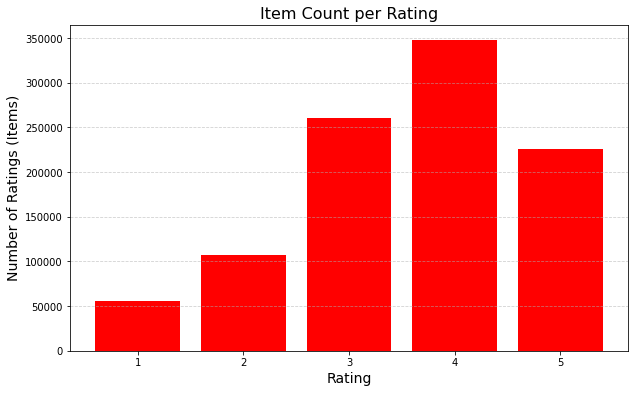

In [35]:
#rating 시각화하기

import matplotlib.pyplot as plt
import pandas as pd

# 예시: 현재 데이터프레임이 tr_dataset.df 라고 가정
df = tr_dataset.df

# 평점별 아이템 개수 세기 (즉, rating 값에 따라 ItemId 수를 count)
rating_counts = df.groupby('Rating')['ItemId'].count()

# 시각화
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values, color='red')

plt.xlabel('Rating', fontsize=14)
plt.ylabel('Number of Ratings (Items)', fontsize=14)
plt.title('Item Count per Rating', fontsize=16)
plt.xticks(rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


 ## Model Architecture

In [36]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, GRU
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

In [37]:
# GRU 기반의 세션 추천 모델 생성 함수
'''
- 입력; args (모델 하이퍼파라미터가 저장된 객체)
- 출력: 컴파일된 keras 모델 객체
'''

def create_model(args):
    inputs = Input(batch_shape=(args.batch_size, 1, args.num_items))
    gru, _ = GRU(args.hsz, stateful=True, return_state=True, name='GRU')(inputs)
    dropout = Dropout(args.drop_rate)(gru) #과적합 방지
    predictions = Dense(args.num_items, activation='softmax')(dropout) #아이템의 수만큼 softmax 확률 분포
    model = Model(inputs=inputs, outputs=[predictions]) #모델 구성
    model.compile(loss=categorical_crossentropy, optimizer=Adam(args.lr), metrics=['accuracy']) #모델 컴파일
    model.summary()
    return model

In [38]:
class Args:
    def __init__(self, tr, val, test, batch_size, hsz, drop_rate, lr, epochs, k):
        self.tr = tr
        self.val = val
        self.test = test
        self.num_items = tr['ItemId'].nunique()
        self.num_sessions = tr['UserId'].nunique()
        self.batch_size = batch_size
        self.hsz = hsz
        self.drop_rate = drop_rate
        self.lr = lr
        self.epochs = epochs
        self.k = k

## 평가 문항 2
* 적절한 epoch만큼의 학습이 진행되는 과정에서 train loss가 안정적으로 감소하고, validation 단계에서의 Recall, MRR이 개선되는 것이 확인된다.

In [39]:
args = Args(tr, val, test, batch_size=128, hsz=50, drop_rate=0.1, lr=0.001, epochs=3, k=20)

In [40]:
model = create_model(args)

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(128, 1, 3415)]          0         
_________________________________________________________________
GRU (GRU)                    [(128, 50), (128, 50)]    520050    
_________________________________________________________________
dropout (Dropout)            (128, 50)                 0         
_________________________________________________________________
dense (Dense)                (128, 3415)               174165    
Total params: 694,215
Trainable params: 694,215
Non-trainable params: 0
_________________________________________________________________


In [41]:
# train 셋으로 학습하면서 valid 셋으로 검증합니다.
def train_model(model, args):
    train_dataset = SessionDataset(args.tr)
    train_loader = SessionDataLoader(train_dataset, batch_size=args.batch_size)

    tf.config.run_functions_eagerly(True)

    for epoch in range(1, args.epochs + 1):
        total_step = len(args.tr) - args.tr['UserId'].nunique()
        tr_loader = tqdm(train_loader, total=total_step // args.batch_size, desc='Train', mininterval=1)
        for feat, target, mask in tr_loader:
            reset_hidden_states(model, mask)  # 종료된 session은 hidden_state를 초기화합니다. 아래 메서드에서 확인해주세요.

            input_ohe = to_categorical(feat, num_classes=args.num_items)
            input_ohe = np.expand_dims(input_ohe, axis=1)
            target_ohe = to_categorical(target, num_classes=args.num_items)

            result = model.train_on_batch(input_ohe, target_ohe)
            tr_loader.set_postfix(train_loss=result[0], accuracy = result[1])

        val_recall, val_mrr = get_metrics(args.val, model, args, args.k)  # valid set에 대해 검증합니다.

        print(f"\t - Recall@{args.k} epoch {epoch}: {val_recall:3f}")
        print(f"\t - MRR@{args.k}    epoch {epoch}: {val_mrr:3f}\n")


def reset_hidden_states(model, mask):
    gru_layer = model.get_layer(name='GRU')  # model에서 gru layer를 가져옵니다.
    hidden_states = gru_layer.states[0].numpy()  # gru_layer의 parameter를 가져옵니다.
    for elt in mask:  # mask된 인덱스 즉, 종료된 세션의 인덱스를 돌면서
        hidden_states[elt, :] = 0  # parameter를 초기화 합니다.
    gru_layer.reset_states(states=hidden_states)


def get_metrics(data, model, args, k: int):  # valid셋과 test셋을 평가하는 코드입니다.
                                                     # train과 거의 같지만 mrr, recall을 구하는 라인이 있습니다.
    dataset = SessionDataset(data)
    loader = SessionDataLoader(dataset, batch_size=args.batch_size)
    recall_list, mrr_list = [], []

    total_step = len(data) - data['UserId'].nunique()

    for inputs, label, mask in tqdm(loader, total=total_step // args.batch_size, desc='Evaluation', mininterval=1):
        reset_hidden_states(model, mask)
        input_ohe = to_categorical(inputs, num_classes=args.num_items)
        input_ohe = np.expand_dims(input_ohe, axis=1) 
        # 
        if input_ohe.shape[0] < args.batch_size:
            pad_len = args.batch_size - input_ohe.shape[0]
            padding = np.zeros((pad_len, 1, args.num_items))
            input_ohe = np.concatenate([input_ohe, padding], axis=0)

        pred = model.predict(input_ohe, batch_size=args.batch_size)


        pred_arg = tf.argsort(pred, direction='DESCENDING')  # softmax 값이 큰 순서대로 sorting 합니다.

        length = len(inputs)
        recall_list.extend([recall_k(pred_arg[i], label[i], k) for i in range(length)])
        mrr_list.extend([mrr_k(pred_arg[i], label[i], k) for i in range(length)])
    
    
    print(recall_list)
    print(mrr_list)
    recall, mrr = np.mean(recall_list), np.mean(mrr_list)
    return recall, mrr

In [42]:
train_model(model, args)

Evaluation:   9%|▉         | 1/11 [00:00<00:05,  1.96it/s]


[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0, 0.16666666666666666, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1111111111111111, 0, 0, 0, 0, 0, 0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0.125, 0, 0, 0.05555555555555555, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.07692307692307693, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	 - Recall@20 epoch 1: 0.073394
	 - MRR@20    epoch 1: 0.015920



Evaluation:   9%|▉         | 1/11 [00:00<00:05,  1.94it/s]


[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.3333333333333333, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0.3333333333333333, 0, 0, 0, 0, 0, 0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.07142857142857142, 0, 0, 0, 0.1111111111111111, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	 - Recall@20 epoch 2: 0.073394
	 - MRR@20    epoch 2: 0.016506



Evaluation:   9%|▉         | 1/11 [00:00<00:05,  1.99it/s]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 0, 0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.09090909090909091, 0, 0, 0, 0.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	 - Recall@20 epoch 3: 0.064220
	 - MRR@20    epoch 3: 0.032027



In [43]:
def test_model(model, args, test):
    test_recall, test_mrr = get_metrics(test, model, args, 20)
    print(f"\t - Recall@{args.k}: {test_recall:3f}")
    print(f"\t - MRR@{args.k}: {test_mrr:3f}\n")

test_model(model, args, test)

Evaluation:   8%|▊         | 1/13 [00:00<00:04,  2.70it/s]

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0.25, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0.1111111111111111, 0, 0, 0, 0, 0, 0, 0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1.0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	 - Recall@20: 0.077922
	 - MRR@20: 0.034560



In [44]:
#1.
args = Args(tr, val, test, batch_size=256, hsz=100, drop_rate=0.5, lr=0.001, epochs=3, k=20)

| 실험명 | 변경 파라미터 | baseline 값 → 변경값 |
| --- | --- | --- |
| 실험 A-1 | `batch_size` | 256 → 128 |
| 실험 A-2 | `batch_size` | 256 → 512 |
| 실험 B-1 | `lr` | 0.001 → 0.0005 |
| 실험 B-2 | `lr` | 0.001 → 0.002 |
| 실험 C-1 | `drop_rate` | 0.1 → 0.5 |
| 실험 C-2 | `drop_rate` | 0.1 → 0.05 |
| 실험 D-1 | `hsz` | 50 → 100 |
| 실험 D-2 | `hsz` | 50 → 25 |

Baseline

args = Args(tr, val, test, batch_size=256, hsz=50, drop_rate=0.1, lr=0.001, epochs=3, k=20)

| Baseline | train loss | recall@20 | MRR@20 |
| --- | --- | --- | --- |
| epoch 1 | `6.73` | `0.018349` | `0.002102` |
| epoch 2 | `6.24` |  `0.055046` | `0.017839` |
| epoch 3 | `6.08` | `0.073394` | `0.024259` |
| Test Model |  |  `0.038961` | `0.003680` |

| 실험명 | 변경 파라미터 | 변경값 | Epoch | Train Loss | Recall@20 | MRR@20 |
| --- | --- | --- | --- | --- | --- | --- |
| A-1 | batch_size | 128 | 1 | `6.35` | `0.073394` | `0.015920` |
|  |  |  | 2 | `5.99` | `0.073394` | `0.016506` |
|  |  |  | 3 | `5.86` | `0.064220` | `0.032027` |
| B-1 | lr | 0.005 | 1 | `6.1` | `0.055046` | `0.008083` |
|  |  |  | 2 | `5.97` | `0.073394` | `0.012113` |
|  |  |  | 3 | `5.94` | `0.073394` | `0.010375` |
| C-1 | drop_rate | 0.5 | 1 | `6.99` | `0.018349` | `0.009748` |
|  |  |  | 2 | `6.54` | `0.064220` | `0.009802` |
|  |  |  | 3 | `6.46` | `0.073394` | `0.015549` |
| C-2 | drop_rate | 0.05 | 1 | `6.63` | `0.027523` | `0.003917` |
|  |  |  | 2 | `6.29` | `0.045872` | `0.010818` |
|  |  |  | 3 | `6.11` | `0.055046` | `0.024305` |
| D-1 | hsz | 100 | 1 | `6.34` | `0.045872` | `0.014424` |
|  |  |  | 2 | `6.04` | `0.045872` | `0.017788` |
|  |  |  | 3 | `5.83` | `0.045872` | `0.019150` |
| D-2 | hsz | 200 | 1 | `6.1` | `0.045872` | `0.011168` |
|  |  |  | 2 | `5.82` | `0.055046` | `0.018691` |
|  |  |  | 3 | `5.7` | `0.073394` | `0.018144`
 |
- **MRR을 높이려면**: `batch_size=128` 조합이 가장 효과적
- **Recall 유지하면서 경량화**: `hsz=25`도 괜찮은 선택
- `lr`, `drop_rate`는 baseline에서 크게 조정할 이유 없음